# 01 — Data Exploration: Football Players Detection

**Goal**: Understand the dataset before training. Check class distribution, image sizes, annotation quality.

**Dataset**: Roboflow `football-players-detection` (4 classes: ball, goalkeeper, player, referee)

### Key things to look for:
1. How many images per split (train/valid/test)?
2. How many objects per class? Is the dataset imbalanced?
3. What do the annotations look like? Are they clean?
4. What are the image dimensions?
5. How many objects per image on average?

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from collections import Counter

# Dataset paths
DATASET_DIR = Path("../data/datasets/football-players-detection")
CLASS_NAMES = ["ball", "goalkeeper", "player", "referee"]
CLASS_COLORS = ["#FF6B6B", "#4ECDC4", "#45B7D1", "#FFA07A"]  # red, teal, blue, orange

# Count images per split
for split in ["train", "valid", "test"]:
    img_count = len(list((DATASET_DIR / split / "images").glob("*")))
    lbl_count = len(list((DATASET_DIR / split / "labels").glob("*")))
    print(f"{split:>5}: {img_count} images, {lbl_count} label files")

train: 612 images, 612 label files
valid: 38 images, 38 label files
 test: 13 images, 13 label files


## Class Distribution

**Why this matters**: If one class is heavily underrepresented (like `ball`), the model will struggle to learn it.
This is common in object detection — small/rare objects are harder.

**YOLO label format reminder**: Each line = `class_id x_center y_center width height` (all normalized 0-1)

In [2]:
def parse_labels(label_dir: Path) -> list[dict]:
    """Parse all YOLO label files and return list of annotations."""
    annotations = []
    for label_file in sorted(label_dir.glob("*.txt")):
        with open(label_file) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 5:
                    cls_id, x_c, y_c, w, h = int(parts[0]), *[float(x) for x in parts[1:]]
                    annotations.append({
                        "file": label_file.stem,
                        "class_id": cls_id,
                        "class_name": CLASS_NAMES[cls_id],
                        "x_center": x_c, "y_center": y_c,
                        "width": w, "height": h
                    })
    return annotations

# Parse training labels
train_anns = parse_labels(DATASET_DIR / "train" / "labels")
valid_anns = parse_labels(DATASET_DIR / "valid" / "labels")

print(f"Total training annotations: {len(train_anns)}")
print(f"Total validation annotations: {len(valid_anns)}")

# Class distribution
train_class_counts = Counter(a["class_name"] for a in train_anns)
print("\nTraining class distribution:")
for cls in CLASS_NAMES:
    count = train_class_counts.get(cls, 0)
    pct = count / len(train_anns) * 100
    print(f"  {cls:>12}: {count:>5} ({pct:.1f}%)")

Total training annotations: 14583
Total validation annotations: 905

Training class distribution:
          ball:   519 (3.6%)
    goalkeeper:   435 (3.0%)
        player: 12228 (83.9%)
       referee:  1401 (9.6%)


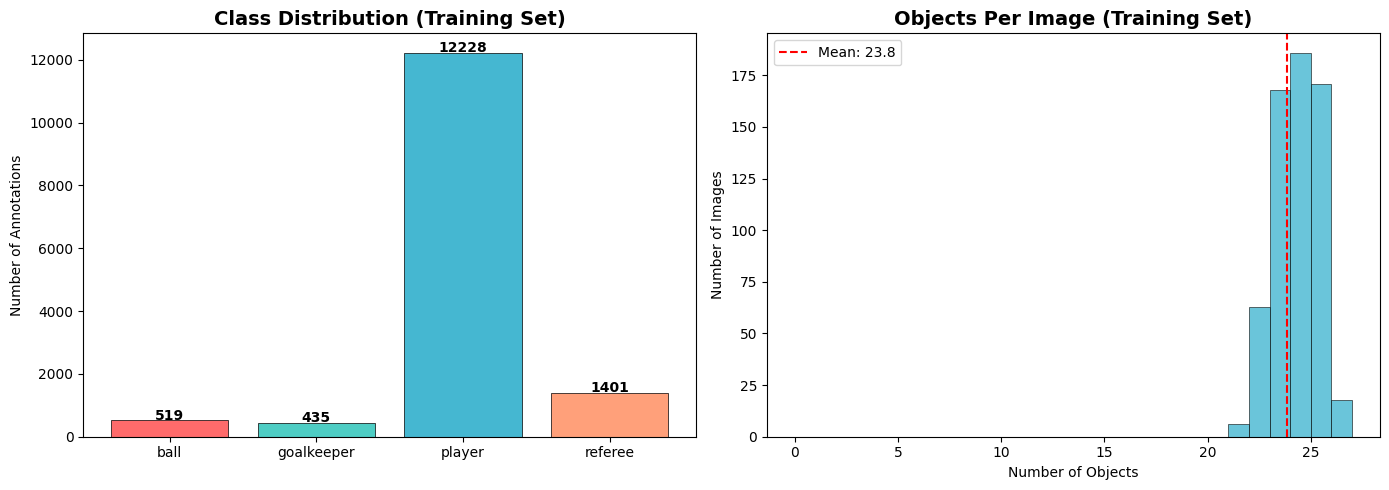


Objects per image — Min: 21, Max: 26, Mean: 23.8, Median: 24


In [3]:
# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
counts = [train_class_counts.get(c, 0) for c in CLASS_NAMES]
bars = axes[0].bar(CLASS_NAMES, counts, color=CLASS_COLORS, edgecolor="black", linewidth=0.5)
axes[0].set_title("Class Distribution (Training Set)", fontsize=14, fontweight="bold")
axes[0].set_ylabel("Number of Annotations")
for bar, count in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 str(count), ha="center", fontweight="bold")

# Objects per image histogram
objs_per_image = Counter(a["file"] for a in train_anns)
obj_counts = list(objs_per_image.values())
axes[1].hist(obj_counts, bins=range(0, max(obj_counts)+2), color="#45B7D1",
             edgecolor="black", linewidth=0.5, alpha=0.8)
axes[1].set_title("Objects Per Image (Training Set)", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Number of Objects")
axes[1].set_ylabel("Number of Images")
axes[1].axvline(np.mean(obj_counts), color="red", linestyle="--", label=f"Mean: {np.mean(obj_counts):.1f}")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nObjects per image — Min: {min(obj_counts)}, Max: {max(obj_counts)}, "
      f"Mean: {np.mean(obj_counts):.1f}, Median: {np.median(obj_counts):.0f}")

## Bounding Box Size Analysis

**Why this matters**: Small bounding boxes (like the ball) are harder to detect.
If `ball` boxes are tiny relative to `player` boxes, we may need special handling later (SAHI, separate model, etc.).

**AV/Robotics parallel**: Same challenge exists with distant pedestrians/vehicles vs nearby ones.

        ball — avg area: 0.0001, avg w: 0.006, avg h: 0.011, count: 519
  goalkeeper — avg area: 0.0006, avg w: 0.012, avg h: 0.045, count: 435
      player — avg area: 0.0008, avg w: 0.014, avg h: 0.052, count: 12228
     referee — avg area: 0.0008, avg w: 0.013, avg h: 0.050, count: 1401


C:\Users\kusha\AppData\Local\Temp\ipykernel_8512\3667884288.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(area_data, labels=labels, patch_artist=True)


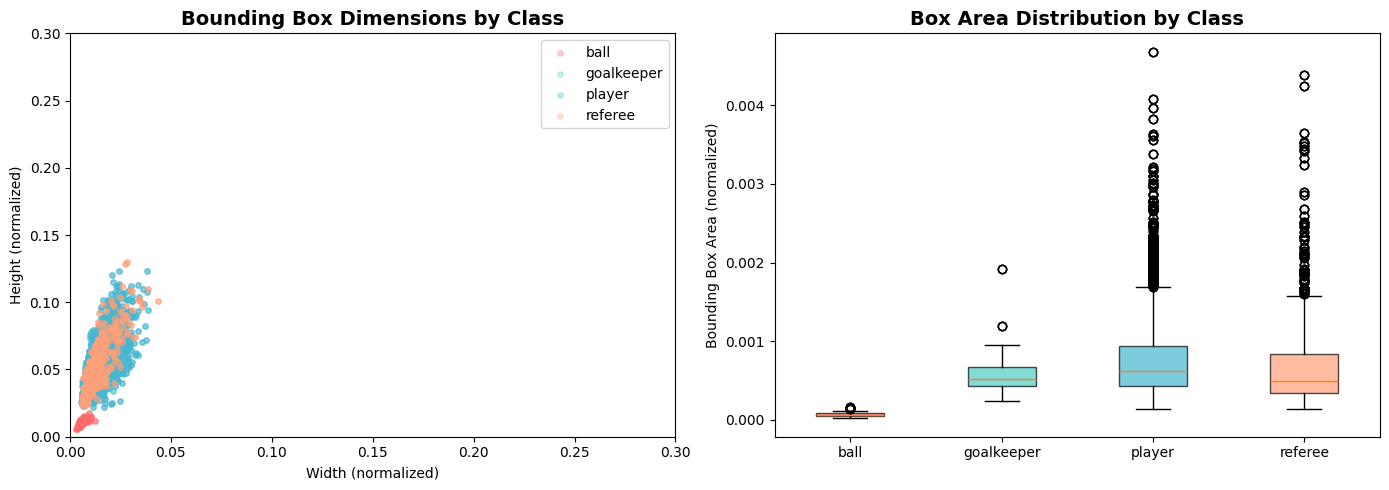

In [4]:
# Bounding box size analysis per class
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for cls_name, color in zip(CLASS_NAMES, CLASS_COLORS):
    cls_anns = [a for a in train_anns if a["class_name"] == cls_name]
    if not cls_anns:
        continue
    widths = [a["width"] for a in cls_anns]
    heights = [a["height"] for a in cls_anns]
    areas = [w * h for w, h in zip(widths, heights)]

    axes[0].scatter(widths, heights, alpha=0.3, s=15, label=cls_name, color=color)
    print(f"{cls_name:>12} — avg area: {np.mean(areas):.4f}, "
          f"avg w: {np.mean(widths):.3f}, avg h: {np.mean(heights):.3f}, count: {len(cls_anns)}")

axes[0].set_xlabel("Width (normalized)")
axes[0].set_ylabel("Height (normalized)")
axes[0].set_title("Bounding Box Dimensions by Class", fontsize=14, fontweight="bold")
axes[0].legend()
axes[0].set_xlim(0, 0.3)
axes[0].set_ylim(0, 0.3)

# Area distribution (box plot)
area_data = []
labels = []
for cls_name in CLASS_NAMES:
    cls_anns = [a for a in train_anns if a["class_name"] == cls_name]
    if cls_anns:
        area_data.append([a["width"] * a["height"] for a in cls_anns])
        labels.append(cls_name)

bp = axes[1].boxplot(area_data, labels=labels, patch_artist=True)
for patch, color in zip(bp["boxes"], CLASS_COLORS[:len(labels)]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_ylabel("Bounding Box Area (normalized)")
axes[1].set_title("Box Area Distribution by Class", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

## Sample Images with Annotations

Let's visually inspect a few images with their bounding boxes to check annotation quality.
Look for:
- Are boxes tight around objects or loose?
- Any obvious mislabels?
- How visible is the ball?

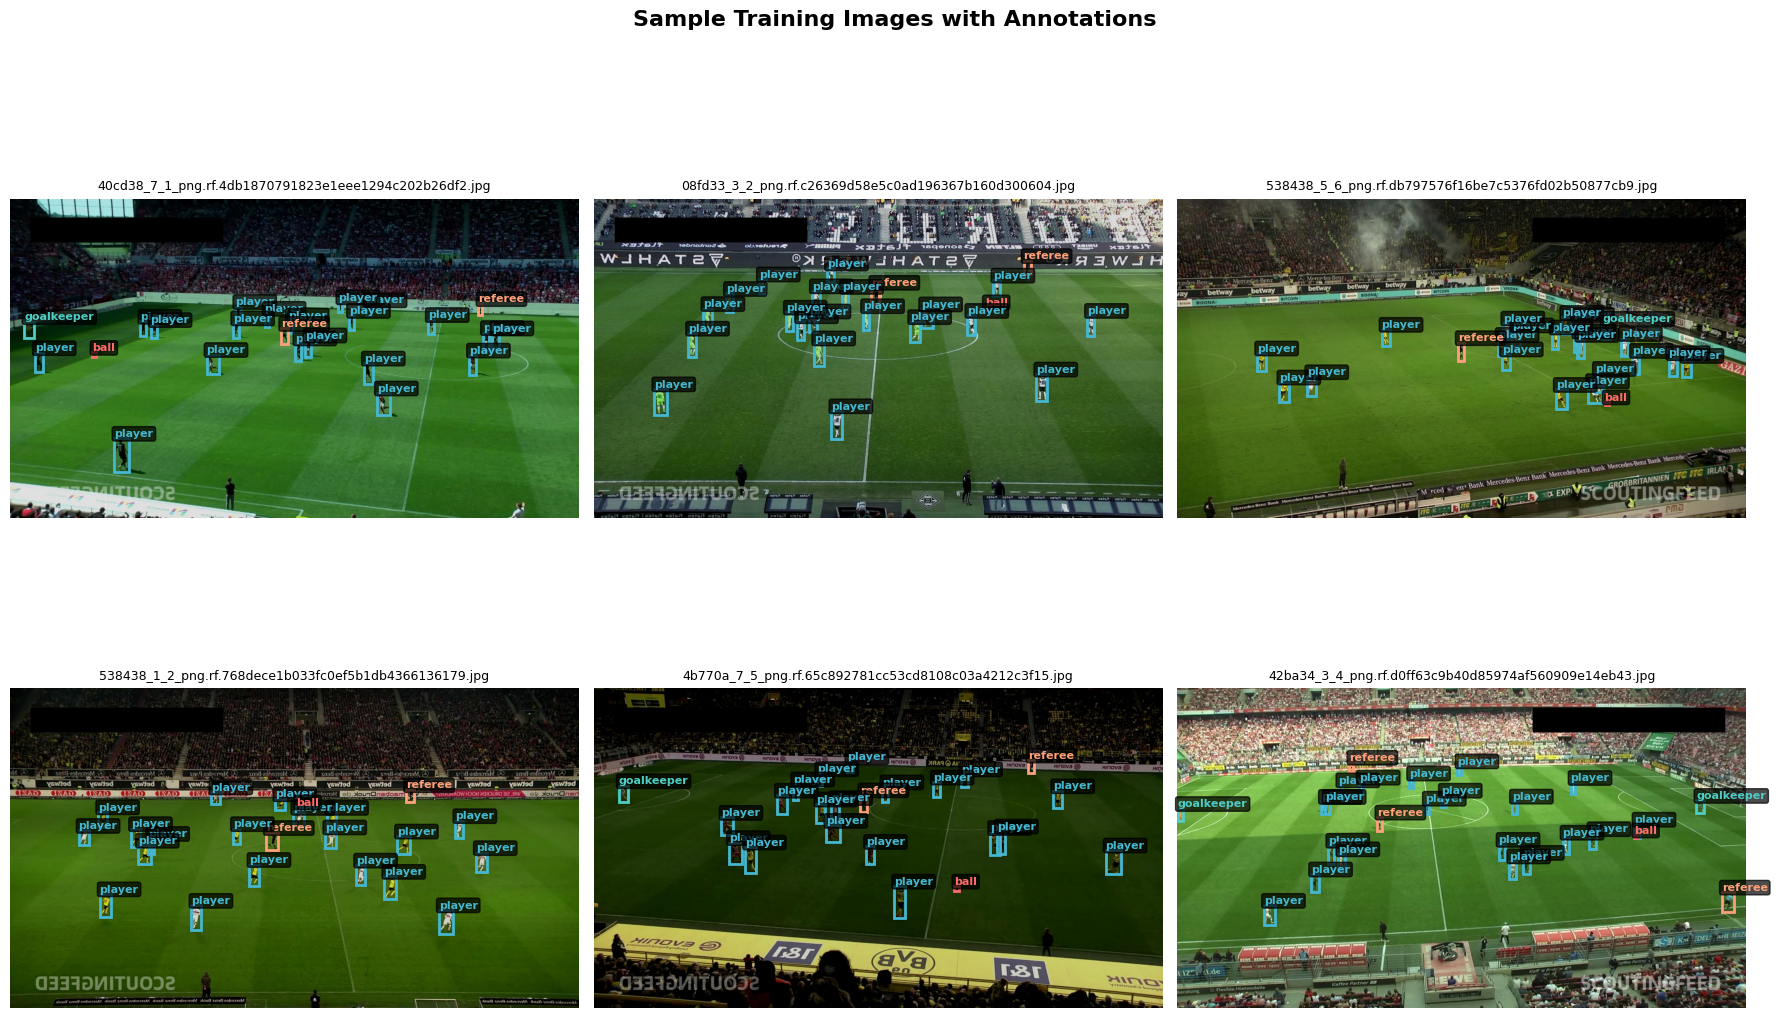

In [5]:
def draw_annotations(img_path: Path, label_path: Path, ax):
    """Draw bounding boxes on an image."""
    img = Image.open(img_path)
    w_img, h_img = img.size
    ax.imshow(img)

    if label_path.exists():
        with open(label_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) != 5:
                    continue
                cls_id = int(parts[0])
                x_c, y_c, bw, bh = [float(x) for x in parts[1:]]

                # Convert normalized coords to pixel coords
                x1 = (x_c - bw/2) * w_img
                y1 = (y_c - bh/2) * h_img
                box_w = bw * w_img
                box_h = bh * h_img

                color = CLASS_COLORS[cls_id]
                rect = patches.Rectangle((x1, y1), box_w, box_h,
                                         linewidth=2, edgecolor=color, facecolor="none")
                ax.add_patch(rect)
                ax.text(x1, y1 - 5, CLASS_NAMES[cls_id], color=color,
                        fontsize=8, fontweight="bold",
                        bbox=dict(boxstyle="round,pad=0.2", facecolor="black", alpha=0.7))

    ax.set_title(img_path.name, fontsize=9)
    ax.axis("off")


# Show 6 random training images
import random
random.seed(42)

train_images = sorted((DATASET_DIR / "train" / "images").glob("*"))
sample_images = random.sample(train_images, min(6, len(train_images)))

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
for ax, img_path in zip(axes.flat, sample_images):
    label_path = DATASET_DIR / "train" / "labels" / (img_path.stem + ".txt")
    draw_annotations(img_path, label_path, ax)

plt.suptitle("Sample Training Images with Annotations", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

## Image Size Check

YOLOv8 resizes input to a square (default 640x640). If images are much larger, there's downscaling.
If they vary wildly in size, that's fine — YOLO handles it with letterboxing (padding).

In [6]:
# Check image sizes
sizes = []
for img_path in (DATASET_DIR / "train" / "images").glob("*"):
    with Image.open(img_path) as img:
        sizes.append(img.size)  # (width, height)

widths, heights = zip(*sizes)
print(f"Image sizes in training set:")
print(f"  Width  — Min: {min(widths)}, Max: {max(widths)}, Unique: {len(set(widths))}")
print(f"  Height — Min: {min(heights)}, Max: {max(heights)}, Unique: {len(set(heights))}")
print(f"  Most common: {Counter(sizes).most_common(3)}")

Image sizes in training set:
  Width  — Min: 1920, Max: 1920, Unique: 1
  Height — Min: 1080, Max: 1080, Unique: 1
  Most common: [((1920, 1080), 612)]


## Summary & Next Steps

**Key observations** (fill in after running cells above):
- Dataset size: 612 train / 38 valid / 13 test
- Class balance: likely `player` dominates, `ball` is rare
- Ball bounding boxes are very small ← hardest class to detect

**Implications for training**:
- Small dataset (612 images) → fine-tuning a pretrained model is essential (not training from scratch)
- Class imbalance → YOLOv8's focal loss helps, but ball detection may need a dedicated model later (Phase 5)
- This dataset is good enough for Phase 1 (player/goalkeeper/referee detection)

**Next**: Fine-tune YOLOv8s on this dataset → `02_train_detector.py`